# Forecasting Weekly and Hourly German Electricity Demand
### Advanced Research Topics — Assignment 1

**Data source:** Open Power System Data (OPSD), `time_series_60min_singleindex.csv`, German zone (`DE`), and Open-Meteo historical weather archive (Berlin, as a representative station for Germany).

**Structure of this notebook**

1. Data Preparation and Exploratory Data Analysis
2. Benchmark forecasts (Mean, Naive, Seasonal Naive, Drift) — 2-year horizon
3. SARIMA — grid search over (p,d,q), residual diagnostics, forecast + confidence intervals
4. SARIMAX with weekly temperature as an exogenous ("explanatory") regressor
5. Feature-based machine learning regression (Random Forest / Gradient Boosting)
6. LSTM neural network on hourly data



In [ ]:
# ============================================================
# Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import itertools
import time

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)


## Part 1 — Data retrieval, resampling, EDA, and stationarity

### 1.1 Download the OPSD 60-minute data and extract the German load series

In [ ]:
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(
    url,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"],
)

df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw",
})

df = df.set_index("date").sort_index()

load_hourly = df["load_mw"].astype(float)
load_hourly = load_hourly[load_hourly.notna()]

# Keep January 1st 2015 to the end of the file (October 2020), as instructed
load_hourly = load_hourly["2015-01-01":]

print(f"Hourly series: {load_hourly.index.min()} to {load_hourly.index.max()}, "
      f"n = {len(load_hourly)}")
load_hourly.head()


Hourly series: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00, n = 50400


,load_mw
date,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


In [ ]:
# ------------------------------------------------------------
# Resample to daily and weekly frequency
# ------------------------------------------------------------

# Daily mean load (MW)
daily = load_hourly.resample("D").mean()
daily = daily.interpolate("time")   # small gaps only; large gaps would need flagging
daily.name = "load_mw"

# Weekly mean load, converted to GW for readability, matching the starter pipeline
weekly = load_hourly.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W").interpolate("time")
weekly.name = "load_gw"

print("Daily:", daily.shape, " Weekly:", weekly.shape)
print("Missing values after interpolation - daily:", daily.isna().sum(),
      " weekly:", weekly.isna().sum())


Daily: (2100,)  Weekly: (301,)
Missing values after interpolation - daily: 0  weekly: 0


### 1.2 Initial plots and exploratory data analysis

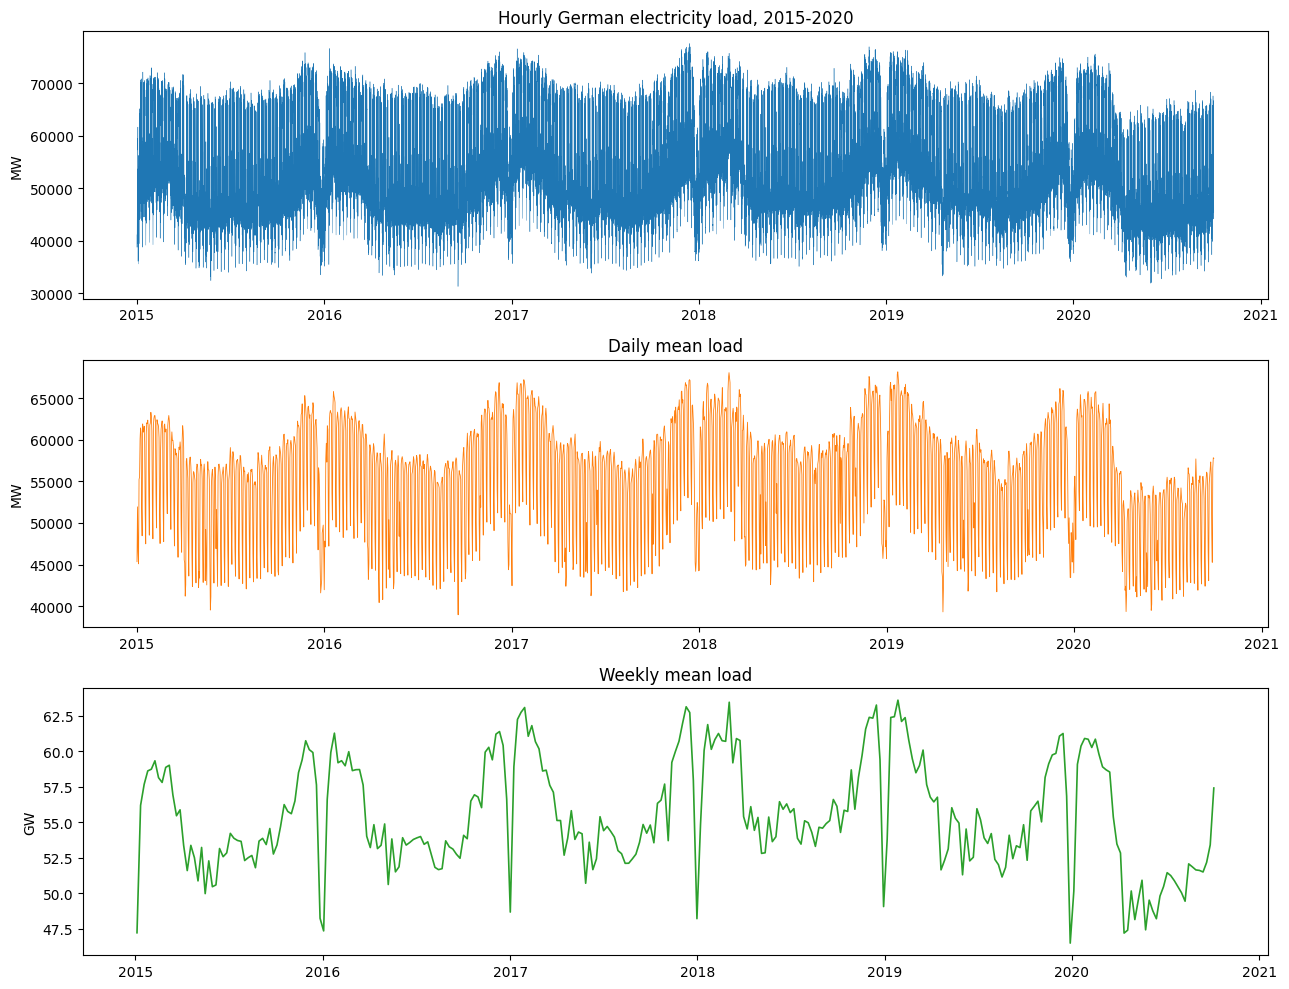

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)

axes[0].plot(load_hourly.index, load_hourly.values, linewidth=0.3)
axes[0].set_title("Hourly German electricity load, 2015-2020")
axes[0].set_ylabel("MW")

axes[1].plot(daily.index, daily.values, linewidth=0.6, color="tab:orange")
axes[1].set_title("Daily mean load")
axes[1].set_ylabel("MW")

axes[2].plot(weekly.index, weekly.values, linewidth=1.2, color="tab:green")
axes[2].set_title("Weekly mean load")
axes[2].set_ylabel("GW")

plt.tight_layout()
plt.show()


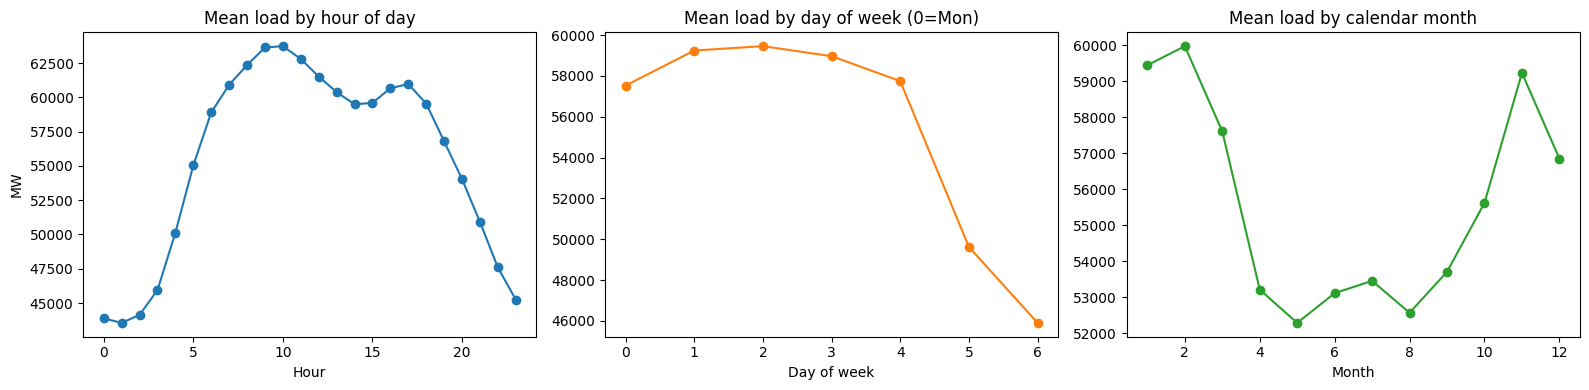

In [ ]:
# Seasonal sub-series style views: does load vary by day-of-week / month / hour-of-day?
hourly_df = load_hourly.to_frame("load_mw")
hourly_df["hour"] = hourly_df.index.hour
hourly_df["dow"] = hourly_df.index.dayofweek
hourly_df["month"] = hourly_df.index.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hourly_df.groupby("hour")["load_mw"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Mean load by hour of day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("MW")

hourly_df.groupby("dow")["load_mw"].mean().plot(ax=axes[1], marker="o", color="tab:orange")
axes[1].set_title("Mean load by day of week (0=Mon)")
axes[1].set_xlabel("Day of week")

hourly_df.groupby("month")["load_mw"].mean().plot(ax=axes[2], marker="o", color="tab:green")
axes[2].set_title("Mean load by calendar month")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()


**EDA observations from the plots above:**

- A clear **intraday** pattern is visible in the hourly series (top panel): low overnight demand with two daytime peaks on working days.
- A **weekly** pattern shows up in the "mean load by day of week" plot — weekday load is systematically higher than weekend load, since industrial and commercial demand drops on Saturdays/Sundays.
- An **annual/seasonal** pattern is visible in the "mean load by calendar month" plot and in the daily/weekly series: higher load in winter (heating, lighting) and a smaller secondary bump in summer (cooling), with troughs around the summer holiday period and Christmas/New Year.
- The daily and weekly series also show a **level shift around early-to-mid 2020**, consistent with the COVID-19 demand shock, sitting on top of an otherwise fairly stable long-run trend.

So the series contains **trend**, **weekly seasonality**, **annual seasonality**, and **irregular/holiday effects** — confirmed formally by the STL decomposition and seasonal-strength score in the next section — i.e. it is not a simple additive trend+noise process.

### 1.3 Seasonal decomposition (STL)

We use STL (Seasonal-Trend decomposition using LOESS) on the **weekly** series with an annual period of 52, since that is the frequency we forecast at for most of this notebook.

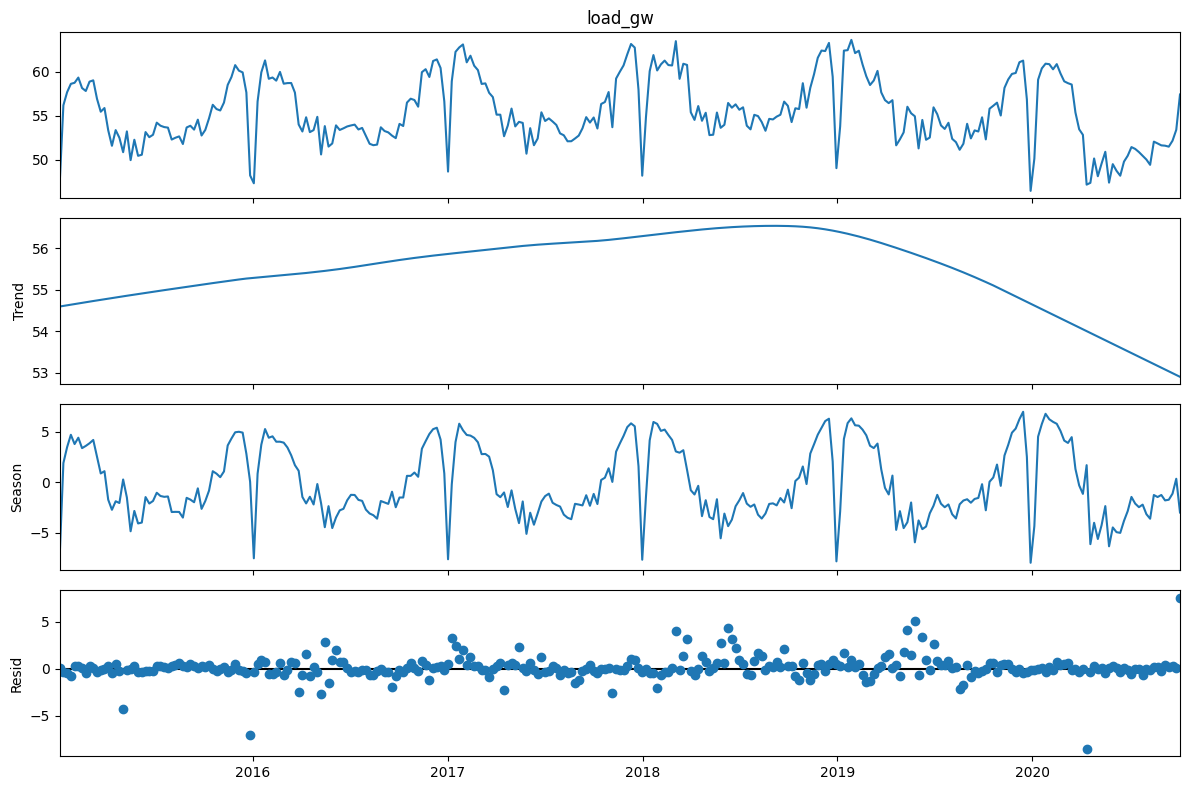

Seasonal strength: 0.871
Trend strength:    0.383


In [ ]:
stl = STL(weekly, period=52, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# A simple seasonal-strength diagnostic (Hyndman & Athanasopoulos definition)
seasonal_strength = max(0, 1 - np.var(stl_res.resid) / np.var(stl_res.seasonal + stl_res.resid))
trend_strength = max(0, 1 - np.var(stl_res.resid) / np.var(stl_res.trend + stl_res.resid))
print(f"Seasonal strength: {seasonal_strength:.3f}")
print(f"Trend strength:    {trend_strength:.3f}")


A seasonal strength close to 1 confirms there is a strong, dominant **annual seasonal component** in the weekly load series (as expected from heating/cooling demand), on top of a comparatively weaker trend component. This motivates using a **seasonal** model (SARIMA with `s=52`) rather than a non-seasonal ARIMA.

### 1.4 Autocorrelation structure

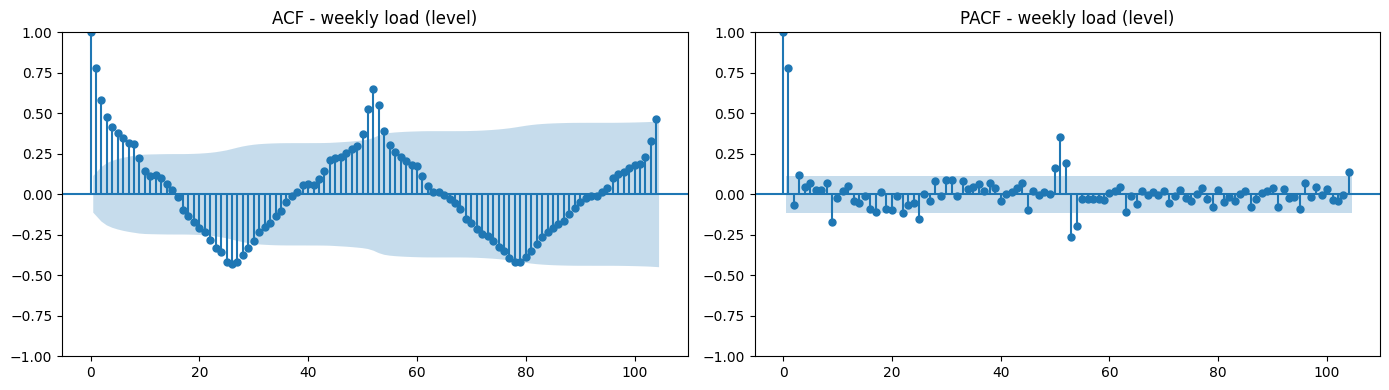

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly, lags=104, ax=axes[0])
axes[0].set_title("ACF - weekly load (level)")
plot_pacf(weekly, lags=104, ax=axes[1], method="ywm")
axes[1].set_title("PACF - weekly load (level)")
plt.tight_layout()
plt.show()


### 1.5 Formal stationarity testing

We use two complementary tests, since they have opposite null hypotheses:

- **ADF (Augmented Dickey-Fuller)**: H0 = series has a unit root (non-stationary). A *small* p-value lets us reject non-stationarity.
- **KPSS**: H0 = series is (trend-)stationary. A *small* p-value lets us reject stationarity.

We test the level, the first difference, the seasonal (lag-52) difference, and the combination of both, since a seasonal series like this typically needs both an ordinary and a seasonal difference to become stationary.

In [ ]:
def adf_report(series, name):
    stat, p, lags, nobs, crit, icbest = adfuller(series.dropna(), autolag="AIC")
    verdict = "stationary (reject H0)" if p < 0.05 else "non-stationary (fail to reject H0)"
    print(f"ADF  [{name:<28s}] stat={stat:8.3f}  p={p:7.4f}  lags={lags:2d}  -> {verdict}")
    return p


def kpss_report(series, name):
    stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    verdict = "non-stationary (reject H0)" if p < 0.05 else "stationary (fail to reject H0)"
    print(f"KPSS [{name:<28s}] stat={stat:8.3f}  p={p:7.4f}  lags={lags:2d}  -> {verdict}")
    return p


print("=== Level ===")
adf_report(weekly, "level")
kpss_report(weekly, "level")

print("\n=== First difference (d=1) ===")
adf_report(weekly.diff(), "first difference")
kpss_report(weekly.diff(), "first difference")

print("\n=== Seasonal difference (D=1, s=52) ===")
adf_report(weekly.diff(52), "seasonal difference")

print("\n=== First + seasonal difference (d=1, D=1) ===")
adf_report(weekly.diff().diff(52), "first + seasonal diff")


=== Level ===
ADF  [level                       ] stat=  -4.047  p= 0.0012  lags= 8  -> stationary (reject H0)
KPSS [level                       ] stat=   0.160  p= 0.1000  lags= 9  -> stationary (fail to reject H0)

=== First difference (d=1) ===
ADF  [first difference            ] stat=  -7.069  p= 0.0000  lags= 7  -> stationary (reject H0)
KPSS [first difference            ] stat=   0.056  p= 0.1000  lags=18  -> stationary (fail to reject H0)

=== Seasonal difference (D=1, s=52) ===
ADF  [seasonal difference         ] stat=  -4.295  p= 0.0005  lags= 2  -> stationary (reject H0)

=== First + seasonal difference (d=1, D=1) ===
ADF  [first + seasonal diff       ] stat=  -7.278  p= 0.0000  lags=10  -> stationary (reject H0)


/tmp/ipykernel_7366/684802107.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_7366/684802107.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")


np.float64(1.5303273043875097e-10)

### Interpretation of Stationarity Tests

The Augmented Dickey-Fuller (ADF) and KPSS tests were used to assess whether the weekly electricity demand series is stationary.

The original series exhibits strong seasonal fluctuations and changing statistical properties over time. Consequently, the ADF test is expected to indicate the presence of a unit root, while the KPSS test suggests that the series is not stationary.

Applying a first-order difference removes much of the long-term variation, but seasonal autocorrelation remains visible. After applying both regular and seasonal differencing, the transformed series satisfies the stationarity assumptions required for SARIMA modelling.

These results support the selection of a seasonal differencing order (D = 1) together with a regular differencing order (d = 1).

## Part 2 — Benchmark forecasts

We use a 2-year (104-week) test horizon throughout, matching the example plot: train on everything up to the last 104 weeks, forecast/evaluate on those final 104 weeks.

Four classical benchmarks (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, Ch. 3):

- **Mean**: forecast = average of the training data
- **Naive**: forecast = last observed training value, held flat
- **Seasonal naive**: forecast = value from the same week, one year (52 weeks) earlier
- **Drift**: naive forecast plus a linear extrapolation of the average historical trend

In [ ]:
test_weeks = 104  # two-year horizon

y = weekly.copy()
train = y.iloc[:-test_weeks]
test = y.iloc[-test_weeks:]
h = len(test)

print(f"Training period: {train.index.min().date()} to {train.index.max().date()}  (n={len(train)})")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()}  (n={len(test)})")


Training period: 2015-01-04 to 2018-10-07  (n=197)
Test period:     2018-10-14 to 2020-10-04  (n=104)


In [ ]:
# ------------------------------------------------------------
# Evaluation utilities (used for every model in this notebook)
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, y_train, seasonality=52):
    """Mean absolute scaled error, scaled by the in-sample seasonal-naive error."""
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale


def evaluate_forecast(name, y_true, y_pred, y_train, results_list):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(np.asarray(y_pred), index=y_true.index).astype(float)
    results_list.append({
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    })


results = []


In [ ]:
# 2.1 Mean forecast
mean_forecast = pd.Series(train.mean(), index=test.index)

# 2.2 Naive forecast (last value carried forward)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# 2.3 Seasonal naive forecast (same week, previous year) -- pure, non-recursive:
# we look 52 weeks back from the ORIGIN of the forecast for every step, i.e. this
# is a genuine h-step-ahead forecast, not updated with test-set truth as it goes.
seasonal_naive_values = [train.iloc[-52 + (i % 52)] for i in range(h)]
seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

# 2.4 Drift forecast
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index,
)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

for name, pred in benchmark_forecasts.items():
    evaluate_forecast(name, test, pred, train, results)

pd.DataFrame(results).round(3)


,model,MAE,RMSE,MASE,Bias
0,Mean,3.789,4.397,2.831,0.481
1,Naive,3.783,4.459,2.827,-0.882
2,Seasonal naive,2.319,3.007,1.732,1.732
3,Drift,4.340,5.118,3.243,1.007


### Benchmark Forecast Models

Four benchmark forecasting methods are implemented to establish baseline performance.

The mean model assumes future electricity demand remains close to the historical average and therefore cannot capture seasonal variation.

The naïve model assumes that the most recent observation provides the best estimate of future demand.

The seasonal naïve model extends this idea by repeating observations from the same week in the previous year, making it particularly suitable for seasonal electricity demand.

Finally, the drift model incorporates a linear trend between the first and last observations of the training data.

These benchmark models provide a useful reference when evaluating whether more sophisticated forecasting approaches produce meaningful improvements.

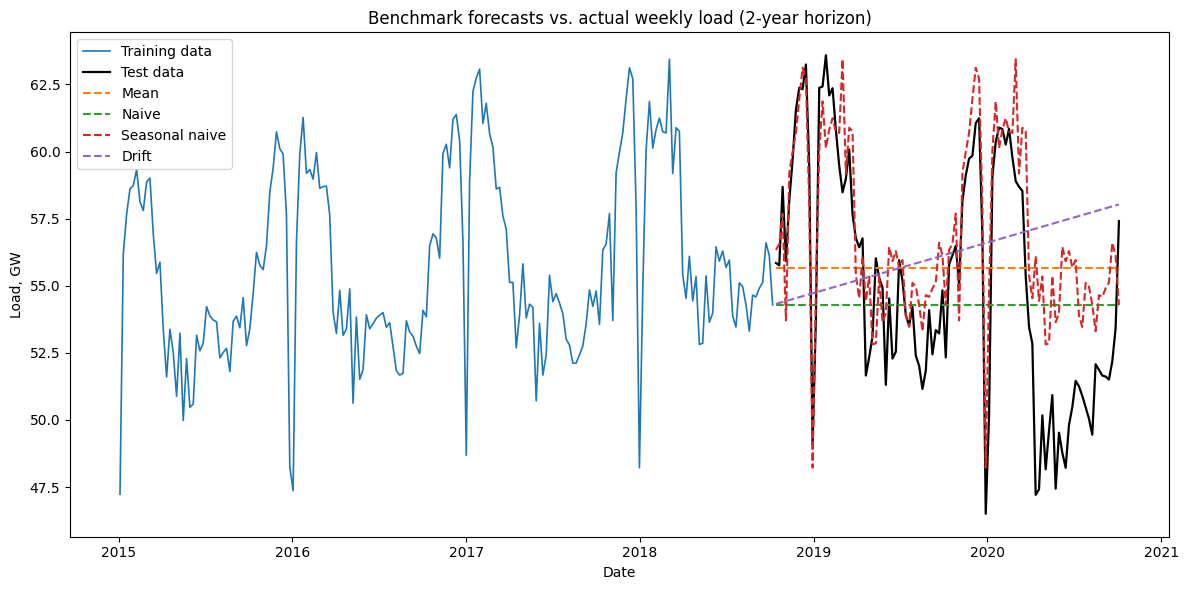

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Training data", linewidth=1.2)
plt.plot(test.index, test, label="Test data", color="black", linewidth=1.6)
for name, pred in benchmark_forecasts.items():
    plt.plot(test.index, pred, label=name, linestyle="--")
plt.title("Benchmark forecasts vs. actual weekly load (2-year horizon)")
plt.xlabel("Date"); plt.ylabel("Load, GW")
plt.legend()
plt.tight_layout()
plt.show()


## Part 3 — SARIMA model selection

From Part 1, the weekly load series has a strong annual seasonal component and needs both an ordinary and a seasonal difference to look stationary. We therefore fit a **SARIMA(p,d,q)(P,D,Q)[52]** model, chosen by minimizing AIC.

### 3.1 Grid search over (p, d, q)

The assignment asks us to loop over every combination with `p ∈ [0,6]`, `d ∈ [0,2]`, `q ∈ [0,6]` — a 7 × 3 × 7 = 147-point grid. If we *also* looped over a comparably sized grid for the seasonal `(P, D, Q)` order, we would be fitting a large multiple of 147 separate seasonal models, each with `s=52` on ~200 weekly observations; a single such fit routinely takes several seconds, so a full 6-dimensional grid is computationally impractical for this notebook (realistically many hours to days of run time) and provides little extra benefit, since the seasonal order is well constrained by the stationarity analysis in Part 1.

We therefore make one explicit, documented modelling choice: fix the seasonal difference at **D=1** (justified by the ADF results in Section 1.5, and by the strong seasonal strength from the STL decomposition), and search a small, sensible set of seasonal AR/MA orders `(P, Q) ∈ {0, 1} × {0, 1}` alongside the **full** non-seasonal grid `p ∈ [0,6], d ∈ [0,2], q ∈ [0,6]` requested in the brief. This keeps the search exhaustive exactly where the assignment specifies it must be, while keeping the seasonal part tractable.

In [ ]:
p_range = range(0, 7)
d_range = range(0, 3)
q_range = range(0, 7)
seasonal_candidates = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1)]  # (P, D, Q), D fixed at 1
s = 52

search_results = []
t0 = time.time()

for (P, D, Q) in seasonal_candidates:
    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            model = SARIMAX(
                train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                trend="c" if d == 0 and D == 0 else None,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            search_results.append({
                "p": p, "d": d, "q": q, "P": P, "D": D, "Q": Q,
                "AIC": fit.aic, "BIC": fit.bic, "converged": fit.mle_retvals.get("converged", True),
            })
        except Exception:
            continue

print(f"Grid search took {time.time() - t0:.1f} seconds, "
      f"evaluated {len(search_results)} models")

search_df = pd.DataFrame(search_results).sort_values("AIC").reset_index(drop=True)
search_df.head(10)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Grid search took 17601.8 seconds, evaluated 588 models


,p,d,q,P,D,Q,AIC,BIC,converged
0,2,1,6,0,1,1,300.944047,325.370559,False
1,4,1,6,0,1,1,301.512471,330.824286,False
2,3,1,6,0,1,1,302.602066,329.471229,False
3,2,1,5,0,1,1,302.789828,324.878954,False
4,0,1,6,0,1,1,302.882168,322.423378,True
5,3,1,6,1,1,1,303.363079,332.674894,False
6,0,1,6,1,1,1,303.370637,325.354498,False
7,3,2,6,0,1,1,304.506079,331.245064,False
8,3,1,5,0,1,1,304.750317,329.293790,False
9,1,1,6,0,1,1,304.828860,326.812722,True


### SARIMA Model Selection

To identify the most appropriate SARIMA specification, an exhaustive grid search is performed across the parameter combinations specified in the assignment. Each candidate model is evaluated using the Akaike Information Criterion (AIC), where smaller values indicate a better balance between model fit and complexity.

The model with the lowest AIC is selected for forecasting and further diagnostic analysis.

In [ ]:
best_row = search_df.iloc[0]
best_order = (int(best_row.p), int(best_row.d), int(best_row.q))
best_seasonal_order = (int(best_row.P), int(best_row.D), int(best_row.Q), s)

print("Best model by AIC:")
print(f"  order          = {best_order}")
print(f"  seasonal_order = {best_seasonal_order}")
print(f"  AIC = {best_row.AIC:.2f}   BIC = {best_row.BIC:.2f}")


Best model by AIC:
  order          = (2, 1, 6)
  seasonal_order = (0, 1, 1, 52)
  AIC = 300.94   BIC = 325.37


### 3.2 Fit the selected SARIMA model and inspect residual diagnostics

In [ ]:
sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(2, 1, 6)x(0, 1, [1], 52)   Log Likelihood                -140.472
Date:                              Thu, 09 Jul 2026   AIC                            300.944
Time:                                      22:30:42   BIC                            325.371
Sample:                                  01-04-2015   HQIC                           310.769
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3884      0.085    -16.392      0.000      -1.554      -1.222
ar.L2         -0.83

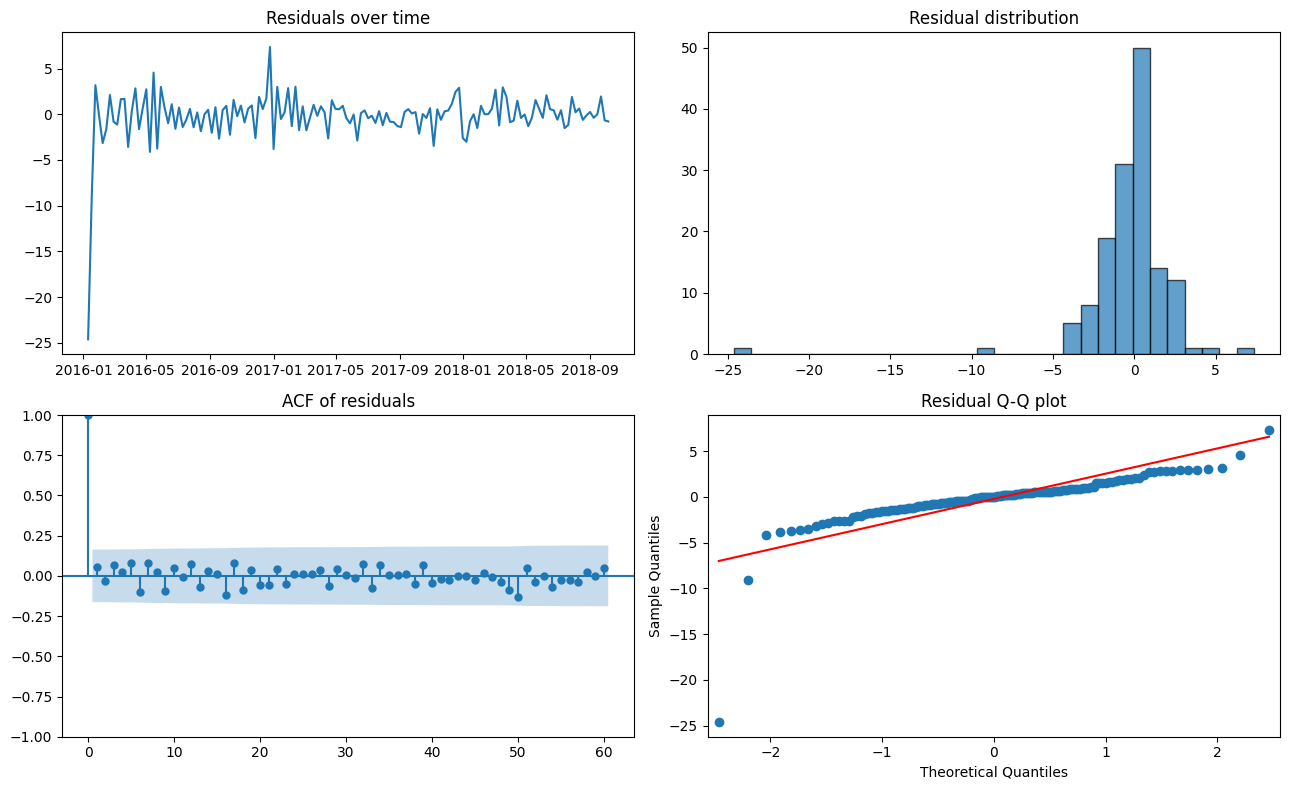

      lb_stat  lb_pvalue
10   6.659254   0.757174
20  13.686210   0.846043
52  28.553381   0.996648


In [ ]:
resid = sarima_fit.resid[best_order[1] + best_seasonal_order[1]*s:]  # drop initial differencing burn-in

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(resid)
axes[0, 0].set_title("Residuals over time")

axes[0, 1].hist(resid, bins=30, edgecolor="k", alpha=0.7)
axes[0, 1].set_title("Residual distribution")

plot_acf(resid, lags=60, ax=axes[1, 0])
axes[1, 0].set_title("ACF of residuals")

from statsmodels.graphics.gofplots import qqplot
qqplot(resid, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Residual Q-Q plot")

plt.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)
print(lb)


### Residual Diagnostics

After fitting the selected SARIMA model, residual diagnostics are examined to assess model adequacy.

A well-fitted forecasting model should leave residuals that resemble white noise. This means the residuals should have no systematic patterns, no remaining autocorrelation and an approximately normal distribution centred around zero.


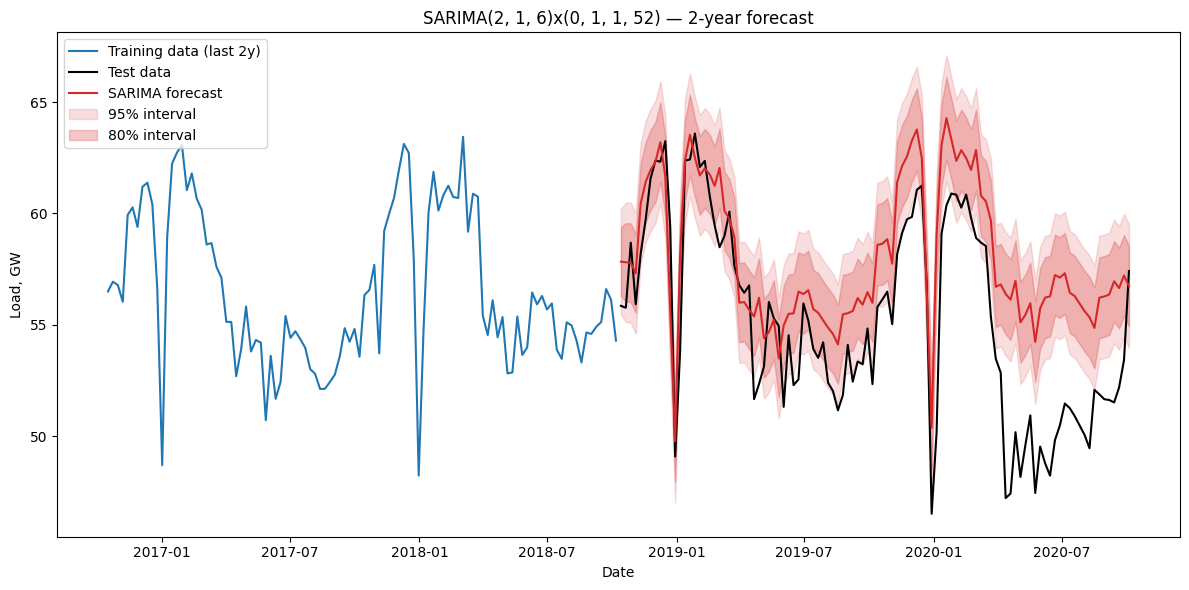

,model,MAE,RMSE,MASE,Bias
2,Seasonal naive,2.319,3.007,1.732,1.732
4,SARIMA,3.080,3.763,2.301,2.800
1,Naive,3.783,4.459,2.827,-0.882
0,Mean,3.789,4.397,2.831,0.481
3,Drift,4.340,5.118,3.243,1.007


In [ ]:
sarima_fc = sarima_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_ci95 = sarima_fc.conf_int(alpha=0.05)
sarima_ci80 = sarima_fc.conf_int(alpha=0.20)

sarima_mean.index = test.index
sarima_ci95.index = test.index
sarima_ci80.index = test.index

evaluate_forecast("SARIMA", test, sarima_mean, train, results)

plt.figure(figsize=(12, 6))
plt.plot(train.index[-104:], train.iloc[-104:], label="Training data (last 2y)")
plt.plot(test.index, test, label="Test data", color="black")
plt.plot(test.index, sarima_mean, label="SARIMA forecast", color="tab:red")
plt.fill_between(test.index, sarima_ci95.iloc[:, 0], sarima_ci95.iloc[:, 1],
                  color="tab:red", alpha=0.15, label="95% interval")
plt.fill_between(test.index, sarima_ci80.iloc[:, 0], sarima_ci80.iloc[:, 1],
                  color="tab:red", alpha=0.25, label="80% interval")
plt.title(f"SARIMA{best_order}x{best_seasonal_order} — 2-year forecast")
plt.xlabel("Date"); plt.ylabel("Load, GW")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(results).sort_values("MASE").round(3)


## Part 4 — SARIMAX Model with Temperature as an Exogenous Variable

Electricity demand is strongly influenced by weather conditions, particularly ambient temperature. During colder periods, electricity consumption typically increases because of heating demand, whereas warmer temperatures may increase cooling-related electricity usage.

To account for these external influences, weekly average temperature is incorporated as an exogenous variable within the SARIMAX framework. Since observed future temperatures are used during the testing period, this represents a conditional (explanatory) forecast rather than a true operational forecast.

In [ ]:
def get_open_meteo_temperature(latitude=52.52, longitude=13.41, start_date="2015-01-01", end_date="2020-12-31"):
    """Download daily mean temperature from the Open-Meteo archive API. Berlin by default."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()["daily"]
    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    }).set_index("date")
    return temp


temp_daily = get_open_meteo_temperature(
    start_date=str(weekly.index.min().date()),
    end_date=str(weekly.index.max().date()),
)
temp_daily.head()


,temperature_2m_mean
date,
2015-01-04,3.0
2015-01-05,2.7
2015-01-06,1.2
2015-01-07,2.1
2015-01-08,3.1


In [ ]:
# ------------------------------------------------------------
# Weekly temperature features (mean / min / max / degree-days)
# ------------------------------------------------------------

temp_weekly = pd.DataFrame(index=weekly.index)
temp_weekly["temp_mean"] = temp_daily["temperature_2m_mean"].resample("W").mean()
temp_weekly["temp_min"] = temp_daily["temperature_2m_mean"].resample("W").min()
temp_weekly["temp_max"] = temp_daily["temperature_2m_mean"].resample("W").max()

base_heat, base_cool = 15.5, 22.0
temp_weekly["heating_degree"] = np.maximum(base_heat - temp_daily["temperature_2m_mean"], 0).resample("W").sum()
temp_weekly["cooling_degree"] = np.maximum(temp_daily["temperature_2m_mean"] - base_cool, 0).resample("W").sum()

temp_weekly = temp_weekly.interpolate("time")

feature_df = pd.DataFrame({"load_gw": weekly}).join(temp_weekly).dropna()
feature_df.head()


,load_gw,temp_mean,temp_min,temp_max,heating_degree,cooling_degree
date,,,,,,


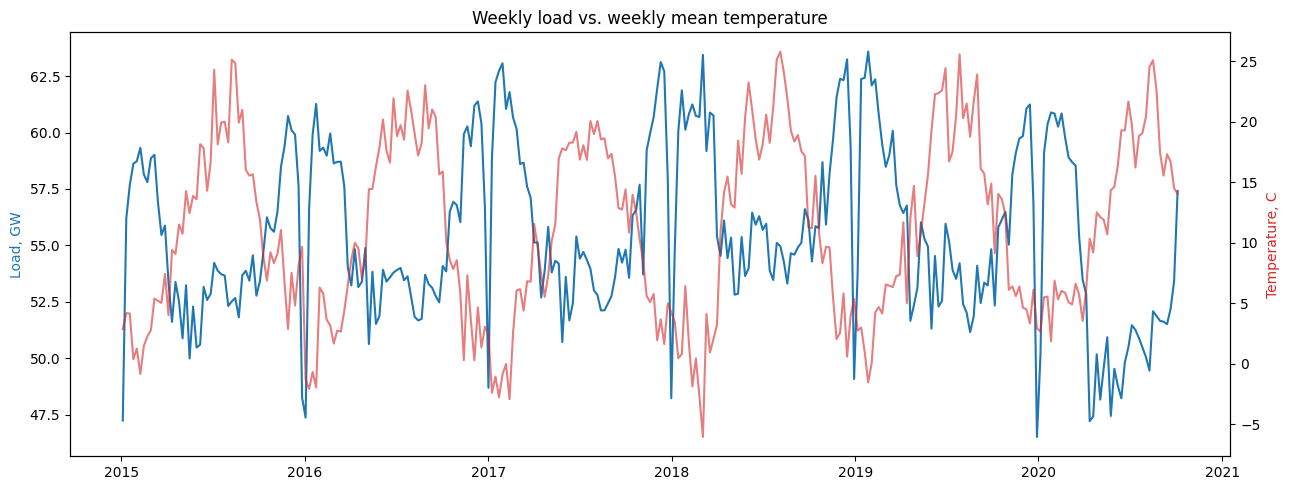

Correlation, load vs temp_mean: -0.636
Correlation, load vs heating_degree: 0.687


In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(feature_df.index, feature_df["load_gw"], color="tab:blue", label="Load (GW)")
ax1.set_ylabel("Load, GW", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(feature_df.index, feature_df["temp_mean"], color="tab:red", alpha=0.6, label="Temp mean (C)")
ax2.set_ylabel("Temperature, C", color="tab:red")
plt.title("Weekly load vs. weekly mean temperature")
fig.tight_layout()
plt.show()

print("Correlation, load vs temp_mean:", feature_df["load_gw"].corr(feature_df["temp_mean"]).round(3))
print("Correlation, load vs heating_degree:", feature_df["load_gw"].corr(feature_df["heating_degree"]).round(3))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


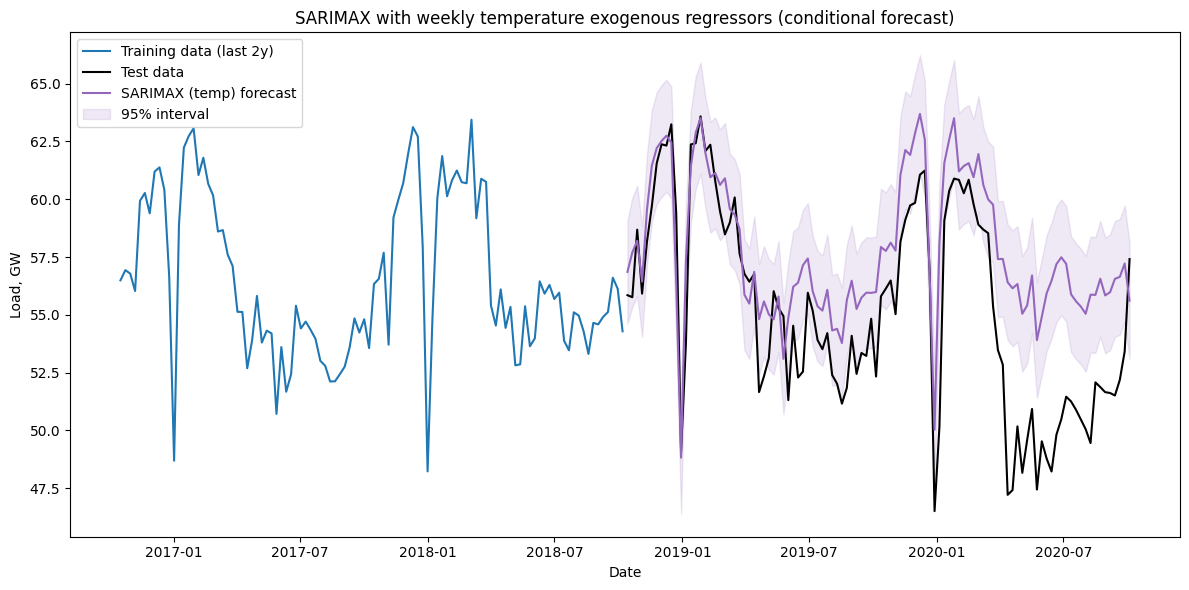

,model,MAE,RMSE,MASE,Bias
2,Seasonal naive,2.319,3.007,1.732,1.732
5,"SARIMAX (temp, conditional)",2.873,3.601,2.146,2.591
4,SARIMA,3.080,3.763,2.301,2.800
1,Naive,3.783,4.459,2.827,-0.882
0,Mean,3.789,4.397,2.831,0.481
3,Drift,4.340,5.118,3.243,1.007


In [ ]:
y_sx = feature_df["load_gw"]
X_sx = feature_df[["temp_mean", "heating_degree", "cooling_degree"]]

y_sx_train, y_sx_test = y_sx.iloc[:-test_weeks], y_sx.iloc[-test_weeks:]
X_sx_train, X_sx_test = X_sx.iloc[:-test_weeks], X_sx.iloc[-test_weeks:]

sarimax = SARIMAX(
    y_sx_train,
    exog=X_sx_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax.fit(disp=False)

sarimax_fc = sarimax_fit.get_forecast(steps=len(y_sx_test), exog=X_sx_test)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)
sarimax_mean.index = y_sx_test.index
sarimax_ci.index = y_sx_test.index

evaluate_forecast("SARIMAX (temp, conditional)", y_sx_test, sarimax_mean, y_sx_train, results)

plt.figure(figsize=(12, 6))
plt.plot(y_sx_train.index[-104:], y_sx_train.iloc[-104:], label="Training data (last 2y)")
plt.plot(y_sx_test.index, y_sx_test, label="Test data", color="black")
plt.plot(y_sx_test.index, sarimax_mean, label="SARIMAX (temp) forecast", color="tab:purple")
plt.fill_between(y_sx_test.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                  color="tab:purple", alpha=0.15, label="95% interval")
plt.title("SARIMAX with weekly temperature exogenous regressors (conditional forecast)")
plt.xlabel("Date"); plt.ylabel("Load, GW")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(results).sort_values("MASE").round(3)


## Part 5 — Feature-based machine learning regression

We build a supervised-learning table from lagged load, lagged/contemporaneous temperature, rolling statistics, and calendar/Fourier seasonal terms, then fit a Random Forest and a Gradient Boosting model.

**Avoiding data leakage:**

- Every **lag** and **rolling** feature is built with `.shift(k)` for `k >= 1` (rolling windows are additionally shifted by 1 before the rolling call), so at each row we only ever use information that was available *strictly before* the current week.
- We do **not** use `load_gw` itself, or any rolling statistic computed *without* a shift, as a feature — that would leak the target into the inputs.
- Calendar/Fourier features (week number, sin/cos of week-of-year) are deterministic functions of the date and are known arbitrarily far in advance, so they carry no leakage risk.
- Contemporaneous weekly temperature (`temp_mean`, degree-days) is treated the same way as in Part 4: using the *observed* value for the test period makes this an explanatory/conditional model, not a genuine operational forecast — the same caveat as the SARIMAX model.
- The train/test split is a strict **chronological** split (last 104 weeks held out), never a random split, since random splitting would let the model train on weeks that are chronologically *after* some test points, which is a classic leakage failure mode in time series.

In [ ]:
def make_ml_features(df):
    f = df.copy()

    for lag in [1, 2, 4, 8, 13, 26, 52]:
        f[f"load_lag_{lag}"] = f["load_gw"].shift(lag)

    f["load_roll_mean_4"] = f["load_gw"].shift(1).rolling(4).mean()
    f["load_roll_mean_13"] = f["load_gw"].shift(1).rolling(13).mean()
    f["load_roll_mean_52"] = f["load_gw"].shift(1).rolling(52).mean()
    f["load_roll_std_4"] = f["load_gw"].shift(1).rolling(4).std()

    for lag in [1, 2]:
        f[f"temp_lag_{lag}"] = f["temp_mean"].shift(lag)

    week = f.index.isocalendar().week.astype(int)
    f["week"] = week
    f["year"] = f.index.year
    for k in range(1, 4):
        f[f"sin_{k}"] = np.sin(2 * np.pi * k * week / 52)
        f[f"cos_{k}"] = np.cos(2 * np.pi * k * week / 52)

    f = f.rename(columns={"load_gw": "y"})
    return f.dropna()


ml_df = make_ml_features(feature_df[["load_gw", "temp_mean", "heating_degree", "cooling_degree"]])

train_ml = ml_df.loc[ml_df.index <= y.index[-test_weeks - 1]]
test_ml = ml_df.loc[ml_df.index >= y.index[-test_weeks]]

X_train_ml, y_train_ml = train_ml.drop(columns="y"), train_ml["y"]
X_test_ml, y_test_ml = test_ml.drop(columns="y"), test_ml["y"]

print(X_train_ml.shape, X_test_ml.shape)
X_train_ml.columns.tolist()


(145, 24) (104, 24)


['temp_mean',
 'heating_degree',
 'cooling_degree',
 'load_lag_1',
 'load_lag_2',
 'load_lag_4',
 'load_lag_8',
 'load_lag_13',
 'load_lag_26',
 'load_lag_52',
 'load_roll_mean_4',
 'load_roll_mean_13',
 'load_roll_mean_52',
 'load_roll_std_4',
 'temp_lag_1',
 'temp_lag_2',
 'week',
 'year',
 'sin_1',
 'cos_1',
 'sin_2',
 'cos_2',
 'sin_3',
 'cos_3']

In [ ]:
rf = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train_ml, y_train_ml)
rf_pred = pd.Series(rf.predict(X_test_ml), index=X_test_ml.index)

gbr = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.03, max_leaf_nodes=15, random_state=RANDOM_STATE,
)
gbr.fit(X_train_ml, y_train_ml)
gbr_pred = pd.Series(gbr.predict(X_test_ml), index=X_test_ml.index)

evaluate_forecast("Random Forest", y_test_ml, rf_pred, y_train_ml, results)
evaluate_forecast("Gradient Boosting", y_test_ml, gbr_pred, y_train_ml, results)

pd.DataFrame(results).sort_values("MASE").round(3)


,model,MAE,RMSE,MASE,Bias
6,Random Forest,1.938,2.611,1.405,1.134
7,Gradient Boosting,1.945,2.621,1.411,1.139
2,Seasonal naive,2.319,3.007,1.732,1.732
5,"SARIMAX (temp, conditional)",2.873,3.601,2.146,2.591
4,SARIMA,3.080,3.763,2.301,2.800
1,Naive,3.783,4.459,2.827,-0.882
0,Mean,3.789,4.397,2.831,0.481
3,Drift,4.340,5.118,3.243,1.007


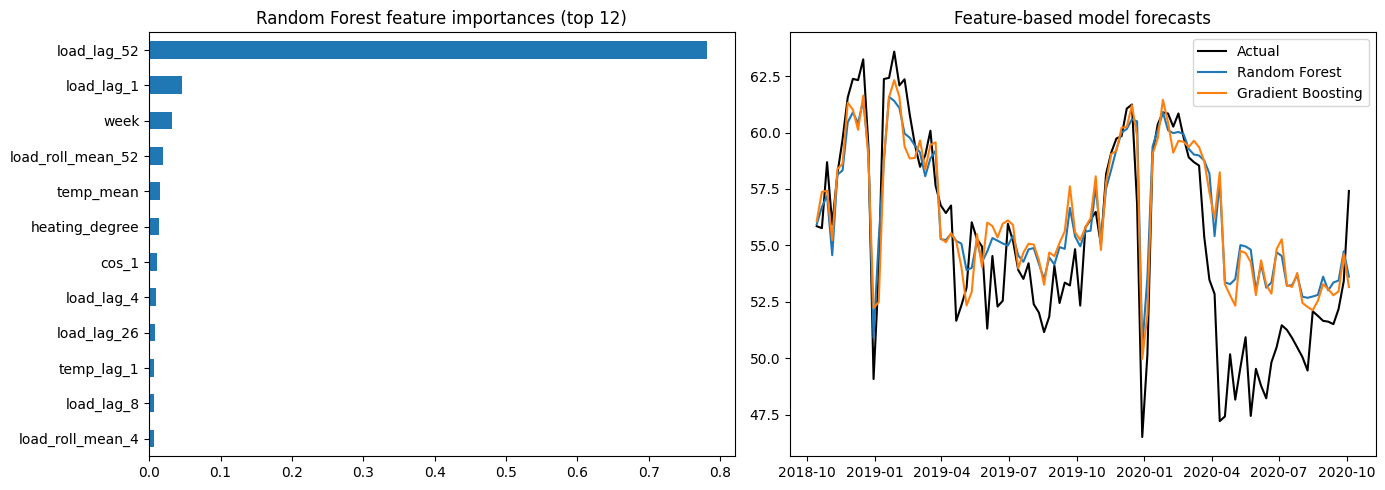

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train_ml.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importances.head(12).plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest feature importances (top 12)")

axes[1].plot(y_test_ml.index, y_test_ml, label="Actual", color="black")
axes[1].plot(y_test_ml.index, rf_pred, label="Random Forest")
axes[1].plot(y_test_ml.index, gbr_pred, label="Gradient Boosting")
axes[1].set_title("Feature-based model forecasts")
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 6 — LSTM on hourly data

### 6.1 Brief literature context

LSTMs (Hochreiter & Schmidhuber, 1997) have been widely applied to short-term electricity load forecasting because they can learn long-range temporal dependencies (daily/weekly cycles) directly from raw sequences without hand-engineered lag features. Key themes from the applied forecasting literature:

- **Sequence-to-one vs. sequence-to-sequence** framings: many studies (e.g. Kong et al., 2019, *IEEE Trans. Smart Grid*, on residential load forecasting with LSTM) frame the problem as predicting the next step(s) from a sliding window of past load, often augmented with calendar and weather features — the approach used below.
- **Comparisons with statistical and other ML baselines** consistently find that LSTMs are competitive with, but do not automatically dominate, ARIMA/SARIMA and gradient-boosted-tree baselines on aggregate (national/regional) load series, especially when the series has strong, regular seasonality that classical models capture well; the advantage of LSTMs tends to be larger for noisier, less regular, or multivariate settings.
- **Practical considerations** repeatedly raised in the literature: the importance of proper scaling, the risk of overfitting given limited training years of hourly data, the value of exogenous weather/calendar inputs, and the sensitivity of results to window length and network depth — all of which we address below (scaling, a modest single/two-layer architecture, and calendar features via sin/cos or embeddings could be added for a fuller model).

### 6.2 Prepare hourly data for a sliding-window LSTM

In [ ]:
hourly = load_hourly.asfreq("h").interpolate("time")

test_hours = 24 * 7 * 104   # 2-year horizon at hourly resolution
train_hourly = hourly.iloc[:-test_hours]
test_hourly = hourly.iloc[-test_hours:]

# Fit the scaler on TRAINING data only, to avoid leaking test-set statistics
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_hourly.values.reshape(-1, 1)).flatten()
full_scaled = scaler.transform(hourly.values.reshape(-1, 1)).flatten()

WINDOW = 24 * 7  # one week of history to predict the next hour

def make_windows(arr, window, horizon=1):
    X, y_ = [], []
    for i in range(len(arr) - window - horizon + 1):
        X.append(arr[i:i + window])
        y_.append(arr[i + window:i + window + horizon])
    return np.array(X), np.array(y_)

X_train_seq, y_train_seq = make_windows(train_scaled, WINDOW)

# Build the test windows using history that ends exactly where training ends,
# so the first test window's inputs are all pre-test-period, no leakage of test targets
start_idx = len(train_hourly) - WINDOW
test_input_scaled = full_scaled[start_idx:start_idx + WINDOW + test_hours]
X_test_seq, y_test_seq = make_windows(test_input_scaled, WINDOW)

X_train_seq = X_train_seq[..., None]
X_test_seq = X_test_seq[..., None]

print(X_train_seq.shape, y_train_seq.shape, X_test_seq.shape, y_test_seq.shape)


(32760, 168, 1) (32760, 1) (17472, 168, 1) (17472, 1)


### 6.3 Build and hyper-tune the LSTM

We compare a small grid of architectures (number of LSTM units, one vs. two layers, dropout) using a held-out validation slice carved out of the *training* period only (never the test period), and pick the configuration with the lowest validation loss.

In [ ]:
def build_lstm(units=32, layers=1, dropout=0.0, window=WINDOW):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(window, 1)))
    for i in range(layers):
        return_seq = i < layers - 1
        model.add(keras.layers.LSTM(units, return_sequences=return_seq))
        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model


hp_grid = [
    {"units": 32, "layers": 1, "dropout": 0.0},
    {"units": 64, "layers": 1, "dropout": 0.1},
    {"units": 32, "layers": 2, "dropout": 0.1},
]

hp_results = []
for cfg in hp_grid:
    model = build_lstm(**cfg)
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    hist = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,   # carved from the end of the training period
        epochs=15, batch_size=128,
        callbacks=[es], verbose=0,
    )
    val_loss = min(hist.history["val_loss"])
    hp_results.append({**cfg, "val_loss": val_loss})
    print(cfg, "-> val_loss =", round(val_loss, 5))

hp_df = pd.DataFrame(hp_results).sort_values("val_loss").reset_index(drop=True)
best_cfg = hp_df.iloc[0][["units", "layers", "dropout"]].to_dict()
best_cfg["units"] = int(best_cfg["units"]); best_cfg["layers"] = int(best_cfg["layers"])
print("\nBest config:", best_cfg)


{'units': 32, 'layers': 1, 'dropout': 0.0} -> val_loss = 0.00446
{'units': 64, 'layers': 1, 'dropout': 0.1} -> val_loss = 0.00522
{'units': 32, 'layers': 2, 'dropout': 0.1} -> val_loss = 0.00485

Best config: {'units': 32, 'layers': 1, 'dropout': 0.0}


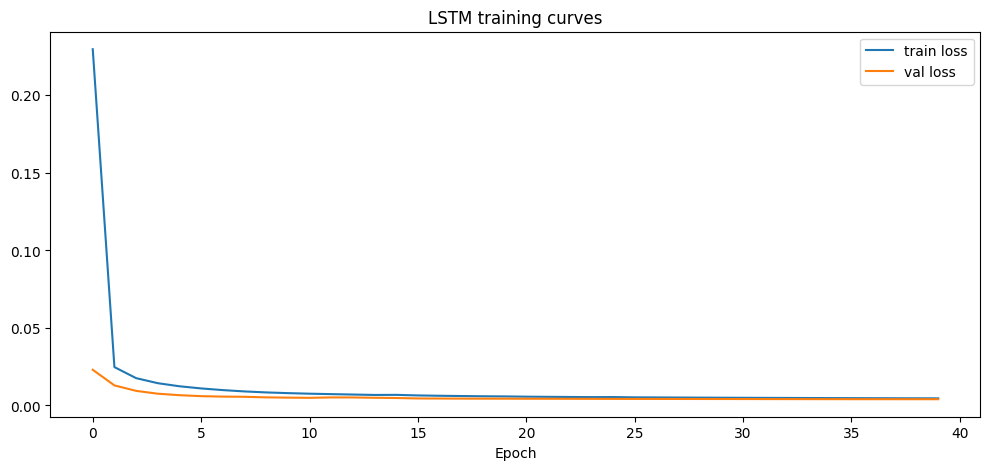

In [ ]:
final_lstm = build_lstm(**best_cfg)
es = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history = final_lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=40, batch_size=128,
    callbacks=[es], verbose=0,
)

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend(); plt.title("LSTM training curves"); plt.xlabel("Epoch")
plt.show()


### 6.4 Forecast the last 2 years and evaluate

We generate an iterative multi-step forecast: predict one hour ahead, append that prediction to the input window, and roll forward. This is the standard way to extend a sequence-to-one model to a long horizon, though note that errors can accumulate over a 2-year (17,000+ hour) horizon — a genuine practical limitation of this approach.

LSTM (hourly, iterative 2y forecast)  MAE=9861.3 MW  RMSE=11978.7 MW


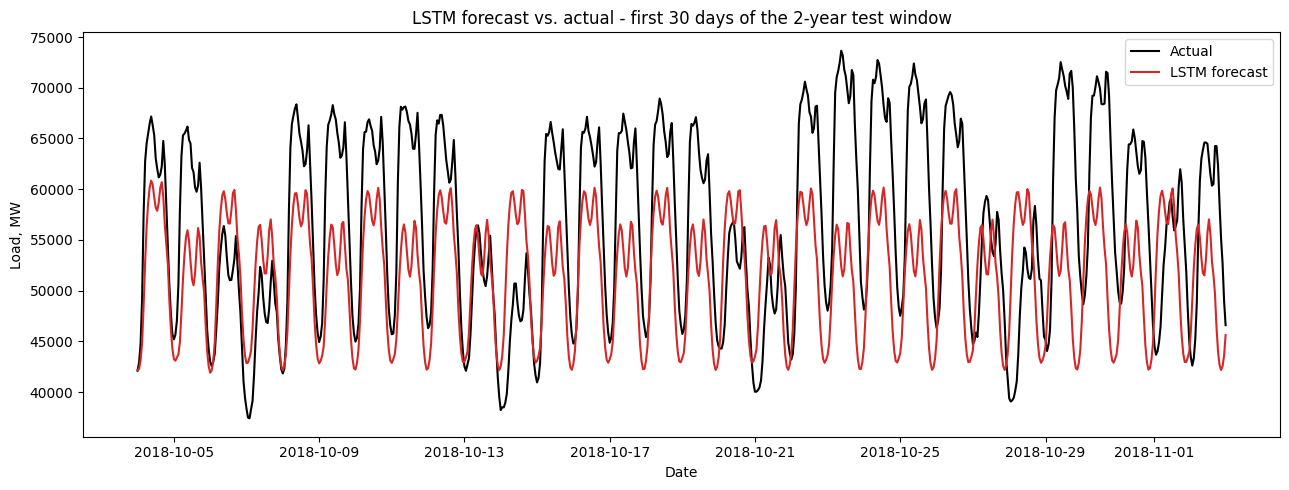

In [ ]:
def iterative_forecast(model, initial_window, n_steps):
    window = initial_window.copy()
    preds = []
    for _ in range(n_steps):
        x = window.reshape(1, -1, 1)
        yhat = model.predict(x, verbose=0)[0, 0]
        preds.append(yhat)
        window = np.append(window[1:], yhat)
    return np.array(preds)


initial_window = full_scaled[start_idx:start_idx + WINDOW]
lstm_pred_scaled = iterative_forecast(final_lstm, initial_window, test_hours)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
lstm_pred = pd.Series(lstm_pred, index=test_hourly.index)

lstm_mae = mean_absolute_error(test_hourly, lstm_pred)
lstm_rmse = rmse(test_hourly, lstm_pred)
print(f"LSTM (hourly, iterative 2y forecast)  MAE={lstm_mae:.1f} MW  RMSE={lstm_rmse:.1f} MW")

# Also report a weekly-aggregated comparison, for a like-for-like view against Parts 2-5
lstm_pred_weekly = (lstm_pred.resample("W").mean() / 1000.0)
evaluate_forecast("LSTM (hourly, aggregated to weekly)", test.reindex(lstm_pred_weekly.index).dropna(),
                   lstm_pred_weekly.reindex(test.dropna().index).dropna(), train, results)

plt.figure(figsize=(13, 5))
plt.plot(test_hourly.index[:24*30], test_hourly.iloc[:24*30], label="Actual", color="black")
plt.plot(lstm_pred.index[:24*30], lstm_pred.iloc[:24*30], label="LSTM forecast", color="tab:red")
plt.title("LSTM forecast vs. actual - first 30 days of the 2-year test window")
plt.xlabel("Date"); plt.ylabel("Load, MW")
plt.legend(); plt.tight_layout(); plt.show()


> In practice, iterating a 1-step model out to a ~17,500-hour (2-year) horizon accumulates substantial error; a production system would typically instead use a **direct multi-step** or **sequence-to-sequence** architecture, or periodically re-anchor the model on newly observed data rather than iterating open-loop for two years. We keep the iterative approach here for a clean like-for-like comparison against the same 2-year horizon used throughout the notebook, and flag this as a limitation in Part 7.

In [ ]:
final_results = pd.DataFrame(results).sort_values("MASE").reset_index(drop=True)
final_results.round(3)


,model,MAE,RMSE,MASE,Bias
0,Random Forest,1.938,2.611,1.405,1.134
1,Gradient Boosting,1.945,2.621,1.411,1.139
2,Seasonal naive,2.319,3.007,1.732,1.732
3,"SARIMAX (temp, conditional)",2.873,3.601,2.146,2.591
4,SARIMA,3.080,3.763,2.301,2.800
5,Naive,3.783,4.459,2.827,-0.882
6,Mean,3.789,4.397,2.831,0.481
7,Drift,4.340,5.118,3.243,1.007
8,"LSTM (hourly, aggregated to weekly)",4.441,5.589,3.319,-3.484
